# 03b — ML training and reconstruction dashboard (pions, π⁺)

**This is the pion (π⁺) sibling of notebook `03`.** It runs the *same* training,
Neyman-inversion, and dashboard machinery as the photon notebook — only the input
dataset and the output ensemble directory change. **Compare your plots with the
photon version (`03`) at every step to see the EM-vs-hadronic differences.** The
headline CALOMAPS result is exactly that comparison: lay the two dashboards side
by side.

This notebook is the heart of CALOMAPS:

1. **Train** a Deep Quantile Ensemble surrogate model for each of the 4 readouts (Analog, MIP, Hits, Cluster) — here, on the π⁺ readouts.
2. **Reconstruct** energy via Neyman inversion of the surrogate.
3. **Plot** the 3-panel physics dashboard.

**What is different for pions.** The DECAL is an *electromagnetic* Si–W
calorimeter: ~25 X₀ deep, but only a *fraction* of a nuclear interaction length
λ_I. A high-energy π⁺ therefore usually does **not** build a full hadronic shower
inside it. Two regimes dominate the π⁺ sample:

- **MIP punch-through (the common case):** the π⁺ crosses the stack as a
  minimum-ionizing particle, leaving a thin, near-straight track of ~MIP hits —
  very few hits, low deposited energy. (EAF-validated: a 50 GeV π⁺ gave ~35
  silicon crossings, versus ~3000 hits for a 50 GeV γ EM shower.)
- **Early hadronic interaction:** a nuclear interaction in the tungsten produces
  a messy, wide, irregular shower with a large electromagnetic sub-component from
  π⁰ → γγ (those EM sub-showers locally look just like the photon showers).

The consequence is not merely that reconstruction is *worse*: for the inclusive
π⁺ sample it effectively **fails**. The readout↔energy map is flat (punch-through
deposits ~the same signal regardless of beam energy) or random (hadronic
interaction at a random, poorly-contained depth), so `σ_reco/E_true` comes out
**huge and nearly the same for all four readouts**, and at low energy it saturates
the Neyman energy grid — i.e. the readout places **no constraint** on the energy at
all. Photons, in the very same detector and reconstruction, give a clean few-%
`a/√E` curve. That contrast — not a small degradation, but a qualitative failure
set against a clean photon curve — is the physics this notebook teaches, and it is
exactly why hadron calorimeters (many nuclear interaction lengths deep) exist.

You need a GPU for training. See [`docs/handbook.md`](../docs/handbook.md) §11.2
for the CUDA torch setup recipe. This notebook is set to **retrain from scratch**
on the π⁺ readouts (`RETRAIN = True`) and writes its own pion-specific ensembles
to `models/saved_ensembles_piplus/` — it does **not** touch the photon
ensembles in `models/saved_ensembles_gpu_v2/`.

**Kernel**: `Key4hep + GPU`. Verify GPU availability in the very first cell.


## 1. Verify the kernel + GPU

In [1]:
import torch, sys
print(f"torch version: {torch.__version__}")
print(f"torch path:    {torch.__file__}")
print(f"cuda built:    {torch.backends.cuda.is_built()}")
print(f"cuda available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print()
    print("WARNING: no CUDA. You're on a CPU-only torch — training will take ~30 min instead of ~9 min.")
    print("To enable GPU: run the following in a cell (then RESTART KERNEL):")
    print("  !pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")


torch version: 2.5.1+cu121
torch path:    /tmp/calomaps_gpu_env/lib/python3.13/site-packages/torch/__init__.py
cuda built:    True
cuda available: True
GPU: NVIDIA A100 80GB PCIe MIG 2g.20gb

Using device: cuda


## 2. Load the extracted dataset

In [2]:
import os, numpy as np
CALOMAPS_HOME = os.environ.get("CALOMAPS_HOME", os.path.expanduser("~/CALOMAPS"))

# Make our analysis utilities importable
sys.path.insert(0, os.path.join(CALOMAPS_HOME, "analysis"))
from quantilenet import QuantileNet, quantile_loss, save_ensemble, load_ensemble, QUANTILES
from dashboard import get_interpolators, reco_metrics_over_grid, plot_dashboard, READOUT_COLORS

# Pion readouts extracted by notebook 02b (the π⁺ sibling of 02).
npz_path = os.path.join(CALOMAPS_HOME, "models", "decal_extracted_data_piplus.npz")
data = np.load(npz_path)
all_truth   = data["all_truth"]
all_visible = data["all_visible"]
all_mip     = data["all_mip"]
all_hits    = data["all_hits"]
all_cluster = data["all_cluster"]
print(f"loaded {len(all_truth)} events from {npz_path}")

# For pions, punch-through events leave very few hits and can land on zero in one
# or more readouts; the >0 mask drops those degenerate events before training.
# Expect a noticeably smaller surviving fraction than the (near-100%) photon case.
valid = (all_hits > 0) & (all_truth > 0) & (all_visible > 0) & (all_mip > 0) & (all_cluster > 0)
x_train = all_truth[valid]
print(f"valid events for training: {valid.sum()}")


loaded 2000 events from /nashome/m/murtazas/CALOMAPS/models/decal_extracted_data_piplus.npz
valid events for training: 2000


## 3. Train the pion ensembles

There are no shipped π⁺ checkpoints, so this notebook **retrains from scratch**
(`RETRAIN = True`). Output goes to `$CALOMAPS_HOME/models/saved_ensembles_piplus/`
— a pion-specific directory, kept separate so we never load or overwrite the
photon ensembles in `saved_ensembles_gpu_v2/`.

Training takes ~10 min on the A100. (If you have already trained the pion
ensembles once, you may flip `RETRAIN = False` to reload them from the same
directory.)


In [3]:
from quantilenet import train_one_ensemble

RETRAIN = True    # retrain the pion ensembles from scratch (no shipped π⁺ checkpoints)
# Pion-specific output dir — do NOT reuse the photon "saved_ensembles_gpu_v2".
ENSEMBLE_DIR = os.path.join(CALOMAPS_HOME, "models", "saved_ensembles_piplus")
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

if RETRAIN:
    # Train all 4 ensembles inline. Takes ~10 min on the A100, ~30-60 min on CPU.
    # Hyperparameters (num_models, epochs, lr, patience) can be passed to
    # train_one_ensemble — see analysis/quantilenet.py for defaults.
    for label, y_arr, seed, fname in [
        ("True Analog",      all_visible, 1000, "ens_analog.pth"),
        ("MIP Proxy",        all_mip,     2000, "ens_mip.pth"),
        ("Raw Hits",         all_hits,    3000, "ens_hits.pth"),
        ("Naive Clustering", all_cluster, 4000, "ens_cluster.pth"),
    ]:
        ens, xmax, ymax = train_one_ensemble(x_train, y_arr[valid], device,
                                              name=label, seed_base=seed)
        save_ensemble(ens, xmax, ymax, os.path.join(ENSEMBLE_DIR, fname))
else:
    print(f"Skipping training. Loading existing ensembles from {ENSEMBLE_DIR}")

# Load all 4 ensembles (either freshly trained above or previously trained)
ens_a, xa, ya = load_ensemble(os.path.join(ENSEMBLE_DIR, "ens_analog.pth"), device)
ens_m, xm, ym = load_ensemble(os.path.join(ENSEMBLE_DIR, "ens_mip.pth"),     device)
ens_h, xh, yh = load_ensemble(os.path.join(ENSEMBLE_DIR, "ens_hits.pth"),    device)
ens_c, xc, yc = load_ensemble(os.path.join(ENSEMBLE_DIR, "ens_cluster.pth"), device)
print(f"loaded 4 ensembles, {len(ens_a)} models each, on device={device}")


=== ensemble: True Analog  (N=2000, x_max=400, y_frac_max=0.0181) ===


  model  1/20  best_val=0.13773  epochs= 1529  (4.8s)


  model  2/20  best_val=0.13766  epochs= 1132  (3.3s)


  model  3/20  best_val=0.13647  epochs= 1316  (4.0s)


  model  4/20  best_val=0.13597  epochs= 1324  (4.4s)


...

  model 17/20  best_val=0.12873  epochs=  612  (2.0s)


  model 18/20  best_val=0.11929  epochs=  599  (1.9s)


  model 19/20  best_val=0.11513  epochs=  551  (1.8s)


  model 20/20  best_val=0.11393  epochs= 1424  (4.6s)
  ensemble total: 49.7s


loaded 4 ensembles, 20 models each, on device=cuda


## 4. The raw data the surrogate learns from

Before any model, look at what we are modeling. Each event gives a true beam
energy `E_true` (here `√(p² + m²)` with the π⁺ mass m = 0.13957 GeV — **not**
massless like a photon) and four *readouts* — different ways the DECAL could
report that energy:

- **True Analog** — total energy deposited in silicon (the ideal analog sum).
- **MIP Proxy** — each hit weighted by `E_hit / E_MIP` (what a MIP-counting chip approximates).
- **Raw Hits** — just the number of lit pixels (the pure digital readout).
- **Naive 2D Clustering** — the count of 8-connected pixel clusters, summed over all layers.

Every readout is a **noisy, possibly non-linear function of `E_true`**. The
scatter below is the entire training set the surrogates see.

**Pion contrast.** Compare this scatter with the same plot in the photon
notebook. For pions expect a far messier picture: a dense **low-readout band**
from MIP punch-through (the π⁺ that crossed as a minimum-ionizing track, depositing
little regardless of `E_true`) plus a sparser, high-variance population from
events that interacted hadronically. The result is a much wider vertical spread
at fixed `E_true` and weaker correlation with energy — the surrogate's job is
harder here, and that shows up later as a worse resolution on the dashboard.

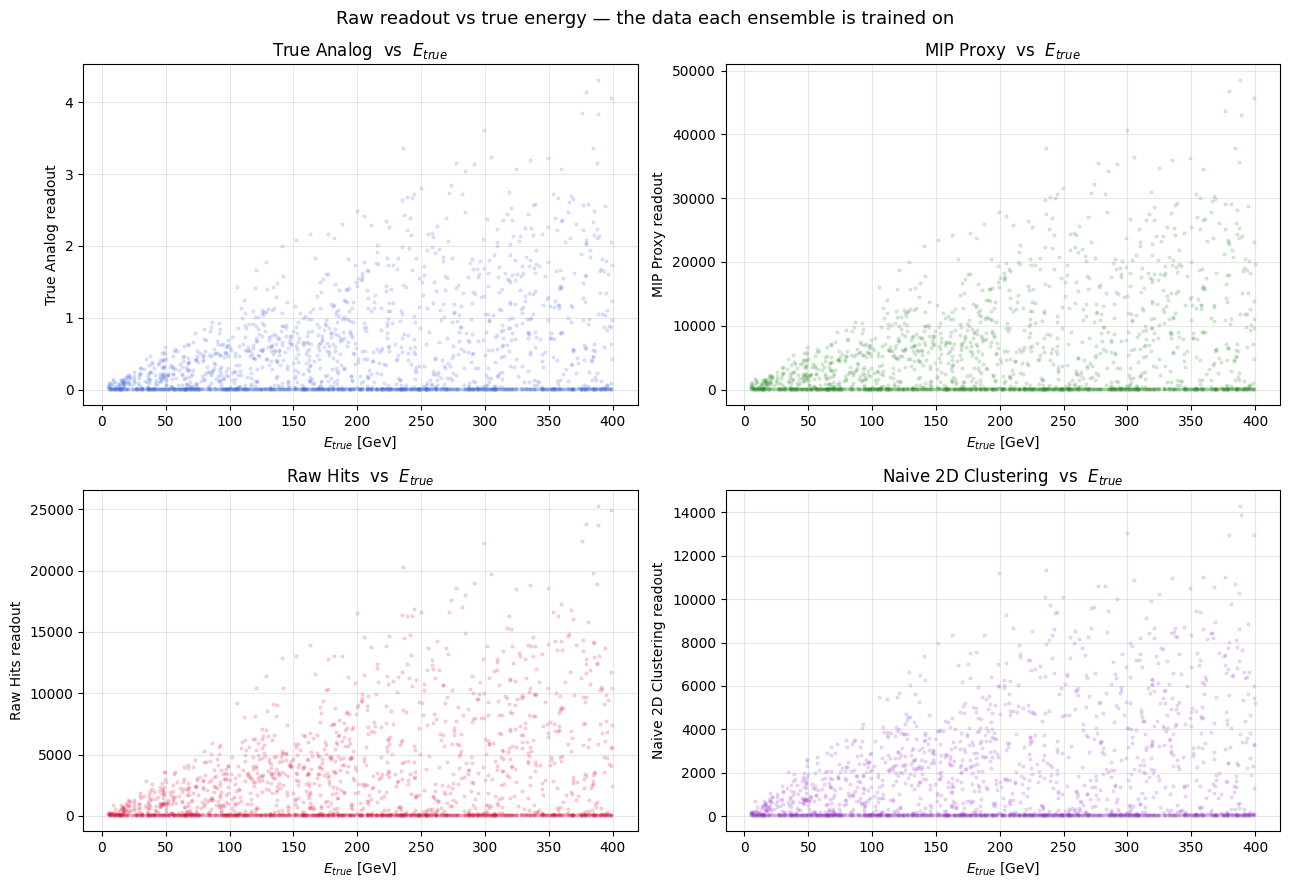

In [4]:
import numpy as np
import matplotlib.pyplot as plt

readouts = {
    "True Analog":          all_visible[valid],
    "MIP Proxy":            all_mip[valid],
    "Raw Hits":             all_hits[valid],
    "Naive 2D Clustering":  all_cluster[valid],
}
colors = {"True Analog": "royalblue", "MIP Proxy": "forestgreen",
          "Raw Hits": "crimson", "Naive 2D Clustering": "darkorchid"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, y) in zip(axes.flat, readouts.items()):
    ax.scatter(x_train, y, s=4, alpha=0.15, color=colors[name])
    ax.set_title(f"{name}  vs  $E_{{true}}$")
    ax.set_xlabel("$E_{true}$ [GeV]")
    ax.set_ylabel(f"{name} readout")
    ax.grid(True, alpha=0.3)
fig.suptitle("Raw readout vs true energy — the data each ensemble is trained on", fontsize=13)
plt.tight_layout()
plt.show()

## 5. What each ensemble learned

Each ensemble is 20 tiny networks. Instead of predicting a single response
value, every network predicts **three quantiles** of the response at a given
`E_true`: the 15.87%, 50%, and 84.13% points — the median and the symmetric ±1σ
envelope of a Gaussian (no Gaussianity is assumed; the
[pinball loss](../analysis/quantilenet.py) simply drives each output to its
target percentile).

So the learned object is not a curve but a **band**:

- the **median** curve is the calibration (typical response vs energy),
- the **half-width** of the band is the intrinsic resolution σ(E) of that readout
  *before* reconstruction.

Overlaying the band on the raw points shows how well 3000 parameters capture the
response.

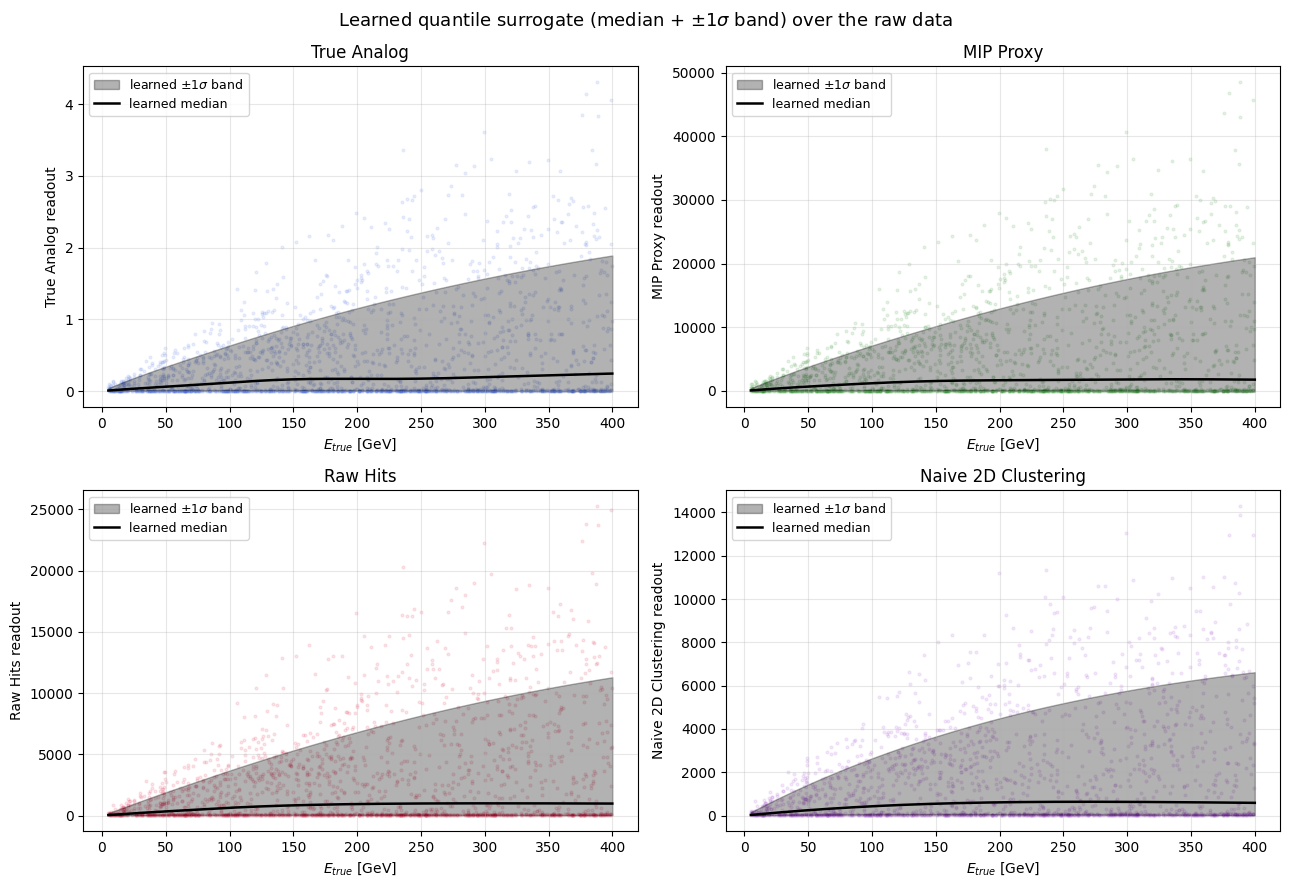

In [5]:
def ensemble_curves(ens, x_max, y_frac_max, e_grid):
    # Ensemble-averaged absolute (low, med, high) readout quantiles vs E.
    xt = torch.tensor(e_grid / x_max, dtype=torch.float32, device=device).unsqueeze(1)
    preds = []
    for m in ens:
        m.eval()
        with torch.no_grad():
            preds.append(m(xt).cpu().numpy())
    avg = np.mean(preds, axis=0) * y_frac_max * e_grid[:, None]
    return avg[:, 0], avg[:, 1], avg[:, 2]

e_grid = np.linspace(5, 400, 400)
ensembles = {
    "True Analog":          (ens_a, xa, ya),
    "MIP Proxy":            (ens_m, xm, ym),
    "Raw Hits":             (ens_h, xh, yh),
    "Naive 2D Clustering":  (ens_c, xc, yc),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, y) in zip(axes.flat, readouts.items()):
    lo, med, hi = ensemble_curves(*ensembles[name], e_grid)
    ax.scatter(x_train, y, s=4, alpha=0.10, color=colors[name])
    ax.fill_between(e_grid, lo, hi, color="black", alpha=0.30, label=r"learned $\pm1\sigma$ band")
    ax.plot(e_grid, med, color="black", lw=1.8, label="learned median")
    ax.set_title(f"{name}")
    ax.set_xlabel("$E_{true}$ [GeV]")
    ax.set_ylabel(f"{name} readout")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle(r"Learned quantile surrogate (median + $\pm1\sigma$ band) over the raw data", fontsize=13)
plt.tight_layout()
plt.show()

### Spread across the ensemble

The band above is the *learned* ±1σ of the response. Separately, the **20 networks
disagree** with each other (they each saw a different bootstrap split) — that
disagreement is the **epistemic** uncertainty. Plotting every member's median *and ±1σ quantile* curves shows how tightly the
ensemble has pinned down both the response and its width.

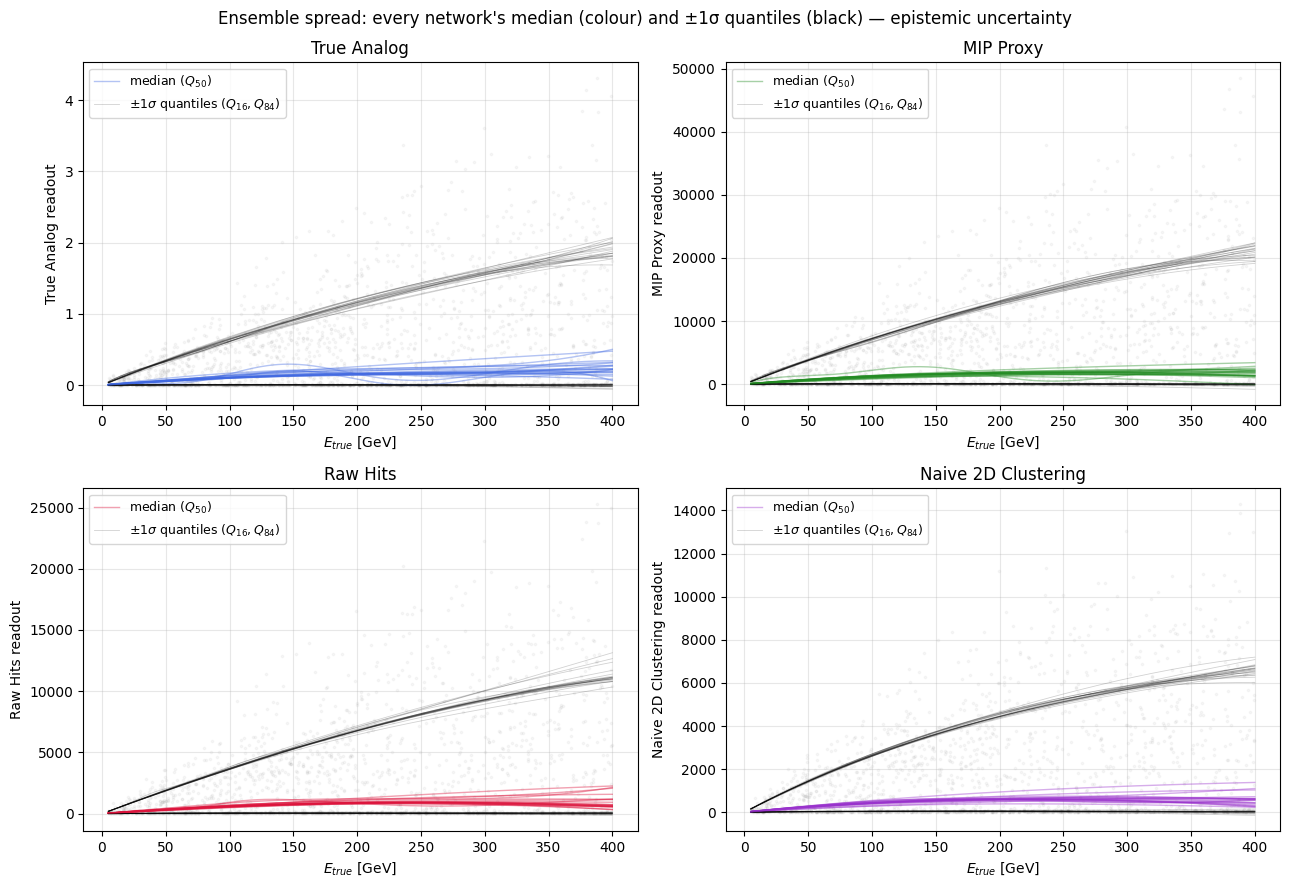

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
e_g = np.linspace(5, 400, 200)
for ax, (name, y) in zip(axes.flat, readouts.items()):
    ens, x_max, y_frac_max = ensembles[name]
    ax.scatter(x_train, y, s=3, alpha=0.06, color="gray")
    xt = torch.tensor(e_g / x_max, dtype=torch.float32, device=device).unsqueeze(1)
    for j, mdl in enumerate(ens):
        mdl.eval()
        with torch.no_grad():
            pa = mdl(xt).cpu().numpy() * y_frac_max * e_g[:, None]   # cols: low, med, high
        ax.plot(e_g, pa[:, 1], color=colors[name], lw=1.0, alpha=0.4,
                label="median ($Q_{50}$)" if j == 0 else None)
        ax.plot(e_g, pa[:, 0], color="black", lw=0.6, alpha=0.18,
                label=r"$\pm1\sigma$ quantiles ($Q_{16}, Q_{84}$)" if j == 0 else None)
        ax.plot(e_g, pa[:, 2], color="black", lw=0.6, alpha=0.18)
    ax.set_title(name); ax.set_xlabel("$E_{true}$ [GeV]"); ax.set_ylabel(f"{name} readout")
    ax.legend(loc="upper left", fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("Ensemble spread: every network's median (colour) and ±1σ quantiles (black) — epistemic uncertainty", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Neyman inversion — from a measurement to an energy

The surrogate runs *forward*: `E_true → response`. Reconstruction is the
*inverse*: given a measured readout `y_obs`, what `E_true` produced it, and with
what uncertainty?

We use a [Neyman construction](../docs/DECAL_pipeline.md):

1. The point estimate is `E_reco = f_med⁻¹(y_obs)` — invert the median curve
   (root-find with Brent's method).
2. The ±1σ interval comes from the **crossover**: invert the *lower* quantile
   curve for the upper energy bound, and the *upper* quantile curve for the lower
   bound. Intuitively, a measurement sitting on the low edge of the band is
   consistent with a higher true energy, and vice versa.

The panels below show this for all four readouts at three example true energies.
Where a readout's curves **flatten** (e.g. Raw Hits at high E, as pixels
saturate), the same `y_obs` maps to a much wider energy interval — exactly the
resolution loss the dashboard will quantify.

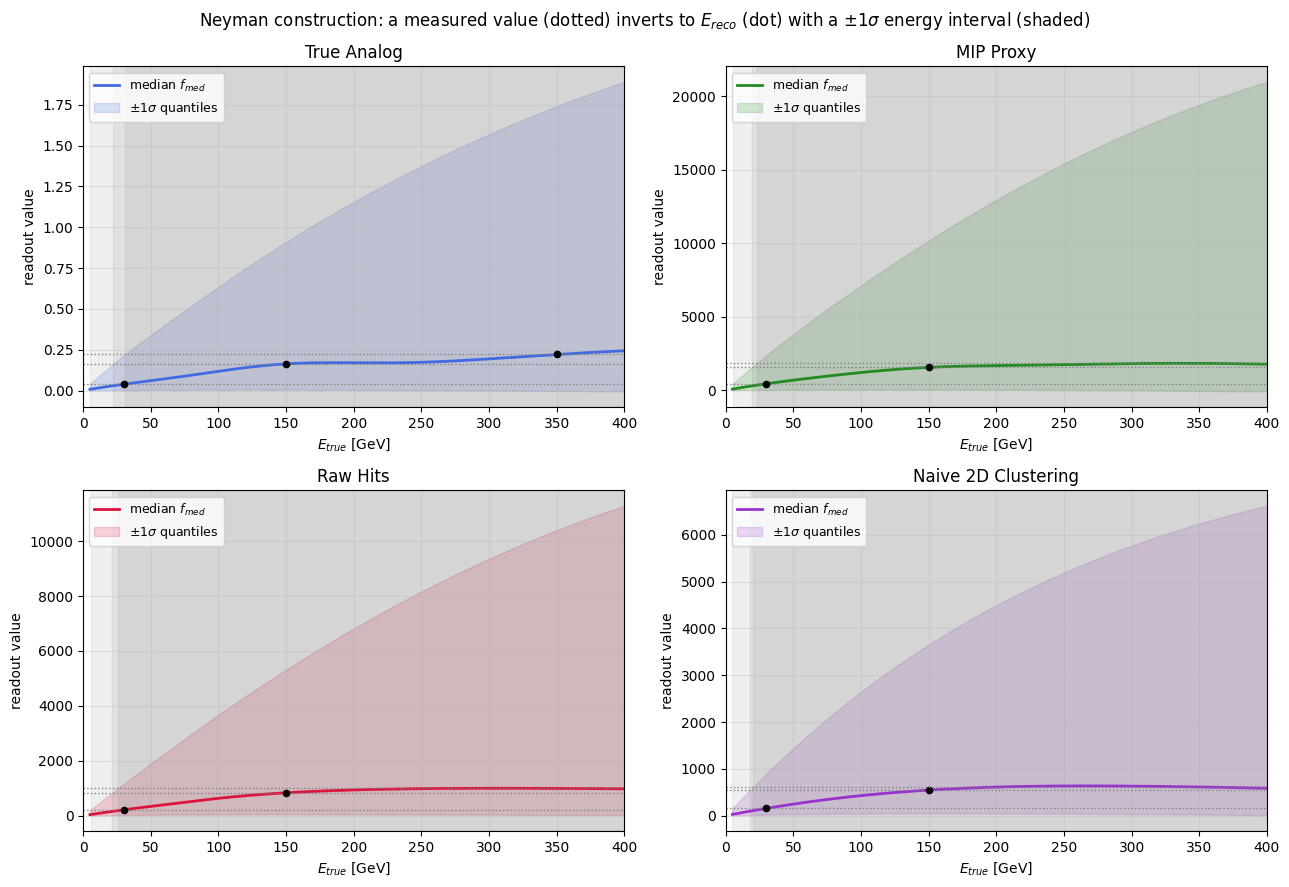

In [7]:
from dashboard import invert_brent

e_grid_inv = np.linspace(1, 500, 1000)   # matches get_interpolators default range
interp = {name: get_interpolators(ens, xm_, ym_, device, e_grid_inv)
          for name, (ens, xm_, ym_) in ensembles.items()}

examples = [30.0, 150.0, 350.0]          # example true energies to invert

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, name in zip(axes.flat, ensembles):
    f_low, f_med, f_high = interp[name]
    eg = np.linspace(5, 400, 400)
    ax.plot(eg, f_med(eg), color=colors[name], lw=2, label=r"median $f_{med}$")
    ax.fill_between(eg, f_low(eg), f_high(eg), color=colors[name], alpha=0.18,
                    label=r"$\pm1\sigma$ quantiles")
    for e_true in examples:
        y_obs  = float(f_med(e_true))
        e_reco = invert_brent(y_obs, f_med)
        e_hi   = invert_brent(y_obs, f_low)    # crossover -> upper bound
        e_lo   = invert_brent(y_obs, f_high)   # crossover -> lower bound
        ax.hlines(y_obs, 0, max(e_hi, e_reco), color="gray", lw=1, ls=":")
        ax.axvspan(e_lo, e_hi, color="gray", alpha=0.12)
        ax.plot([e_reco], [y_obs], "k.", ms=9)
    ax.set_title(f"{name}")
    ax.set_xlabel("$E_{true}$ [GeV]")
    ax.set_ylabel("readout value")
    ax.set_xlim(0, 400)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("Neyman construction: a measured value (dotted) inverts to $E_{reco}$ (dot) "
             r"with a $\pm1\sigma$ energy interval (shaded)", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Reconstruct over the full energy grid

Run the inversion across a dense grid of true energies for every readout,
collecting the response ratio (for the closure check above) and the ±1σ
resolution at each energy. The interpolators built in section 6 are reused.

In [8]:
reco = {
    "Analog":  reco_metrics_over_grid(*interp["True Analog"]),
    "MIP":     reco_metrics_over_grid(*interp["MIP Proxy"]),
    "Hits":    reco_metrics_over_grid(*interp["Raw Hits"]),
    "Cluster": reco_metrics_over_grid(*interp["Naive 2D Clustering"]),
}

# Print headline numbers
et = reco["Analog"][0]
print("\n=== reconstructed resolutions (sigma_reco / E_true) ===")
for energy in (10, 100, 300):
    idx = np.argmin(np.abs(et - energy))
    print(f"  E={energy:>3d} GeV:  ", end="")
    for key in ("Analog", "MIP", "Hits", "Cluster"):
        print(f"{key.lower()}={reco[key][2][idx]:.4f}  ", end="")
    print()


=== reconstructed resolutions (sigma_reco / E_true) ===
  E= 10 GeV:  analog=22.2500  mip=22.2500  hits=22.2500  cluster=22.2500  
  E=100 GeV:  analog=2.1579  mip=2.1621  hits=2.1549  cluster=2.1666  
  E=300 GeV:  analog=0.7015  mip=0.7086  hits=0.7034  cluster=0.7116  


## 8. How well does the inversion close?

Reconstruction should be **unbiased**: feeding the median response of a true
energy back through the inverse must return that same energy. The left panel
checks closure (`E_reco` vs `E_true`, should lie on `y = x`); the right panel is
the bias `E_reco/E_true − 1` in percent — flat at zero means a faithful
inversion.

This closure is *near-perfect by construction* (we invert the same median we
built), so it is a sanity check, not a resolution measurement — the real physics
is the band *width*, shown in the dashboard next. See
[handbook §13.1](../docs/handbook.md) for the caveat.

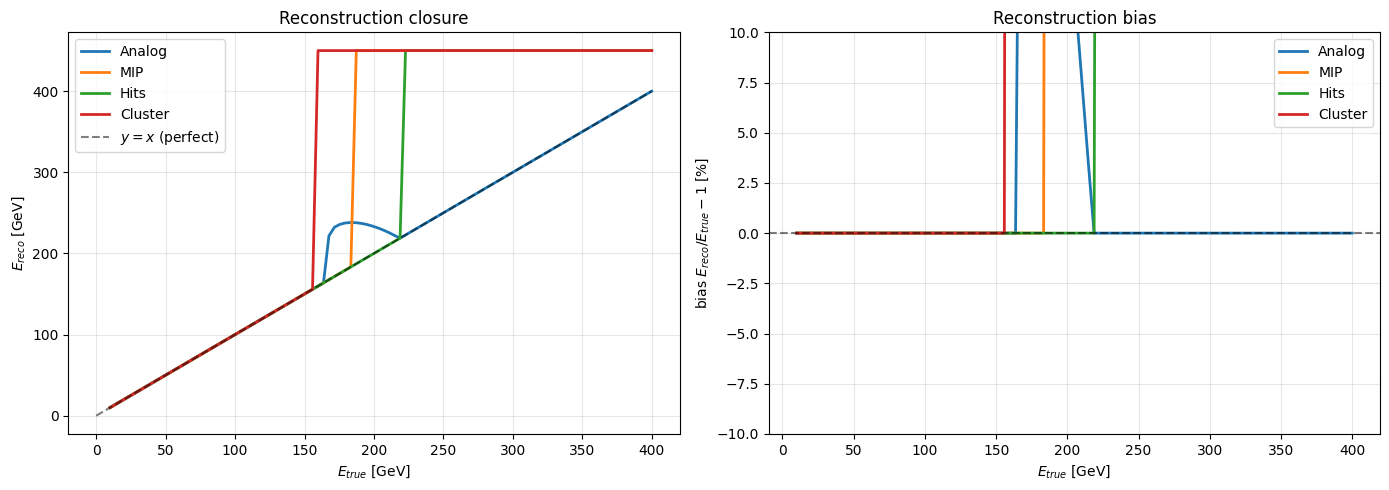

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for key in ("Analog", "MIP", "Hits", "Cluster"):
    e_t, resp, res = reco[key]
    axes[0].plot(e_t, e_t * resp, lw=2, label=key)
axes[0].plot([0, 400], [0, 400], "k--", alpha=0.5, label="$y=x$ (perfect)")
axes[0].set_xlabel("$E_{true}$ [GeV]"); axes[0].set_ylabel("$E_{reco}$ [GeV]")
axes[0].set_title("Reconstruction closure"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for key in ("Analog", "MIP", "Hits", "Cluster"):
    e_t, resp, res = reco[key]
    axes[1].plot(e_t, (resp - 1.0) * 100, lw=2, label=key)
axes[1].axhline(0, color="black", ls="--", alpha=0.5)
axes[1].set_ylim(-10, 10)
axes[1].set_xlabel("$E_{true}$ [GeV]"); axes[1].set_ylabel(r"bias $E_{reco}/E_{true}-1$ [%]")
axes[1].set_title("Reconstruction bias"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. The resolution dashboard

The payoff. Three panels: reconstructed linearity, resolution vs energy (the
saturation knee), and the stochastic term (σ/E vs 1/√E).

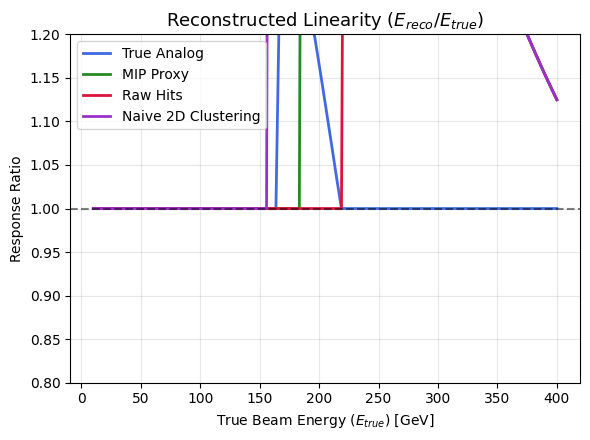

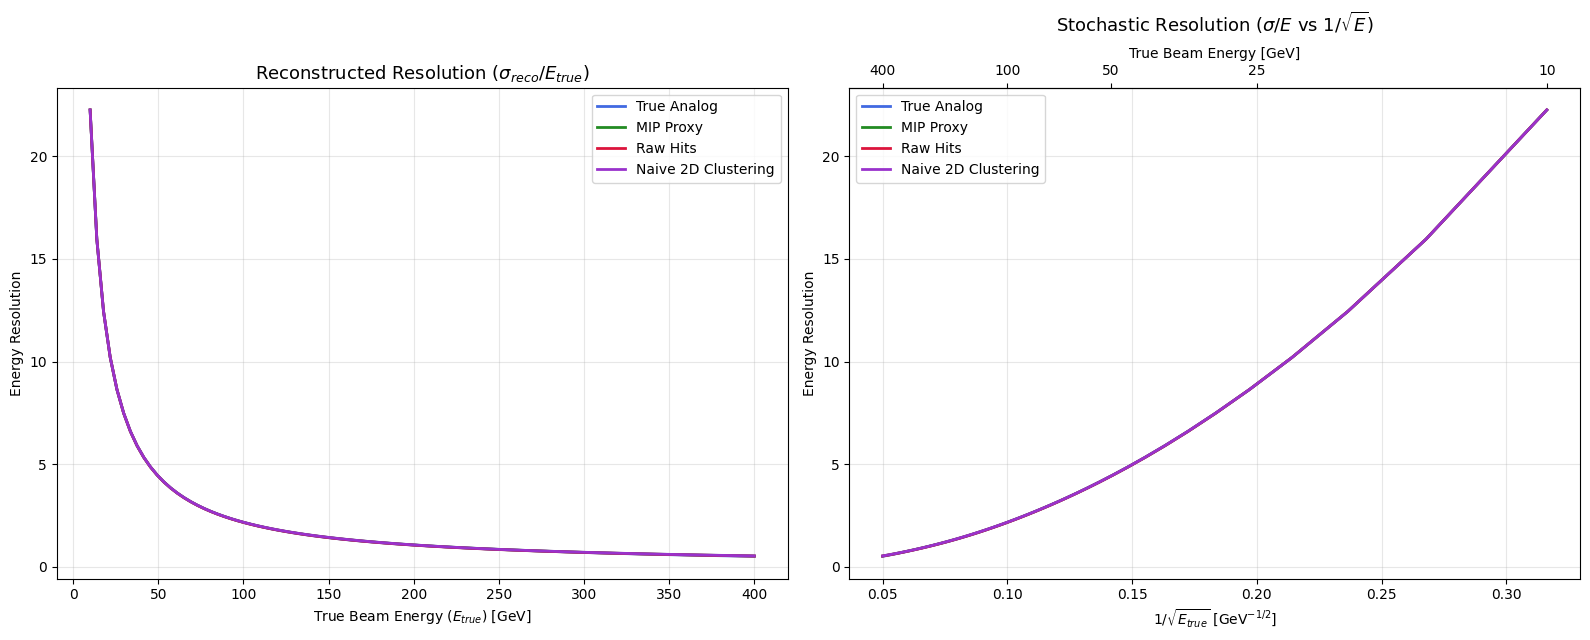

In [10]:
plot_dashboard(reco, out_path_prefix=None, show=True)


## Photon vs pion: the reconstruction is markedly different

The sections above trained and inverted the surrogate on the **pion** readouts in
isolation. The point of CALOMAPS, though, is the *contrast* with photons. This
section loads the **photon** ensembles and photon dataset and runs them through
the **exact same** Neyman-inversion helpers, then puts the two side by side on a
single set of axes. No new machinery — same `get_interpolators`,
`reco_metrics_over_grid`, `invert_brent` calls, same energy grid — so the overlay
is genuinely apples-to-apples.

What you are about to see is not "pions are a bit worse." It is **qualitatively
different**: photons reconstruct cleanly (a falling few-percent `a/√E` resolution
curve), while the pion `σ_reco/E_true` is high, nearly flat, and almost the *same
for all four readouts* — and at low energy it **saturates the Neyman energy grid**,
which means the readout puts essentially **no constraint** on the energy at all.
That saturated value is an artifact of the inversion hitting the edge of the grid,
**not** a resolution you can read off as a number.

> **Comparison requires the photon assets.** The cells below load
> `models/saved_ensembles_gpu_v2/` and `models/decal_extracted_data.npz`. If those
> are missing, the cells print a notice and skip gracefully — run notebooks
> **02** and **03** (the photon arm) first to enable the comparison.

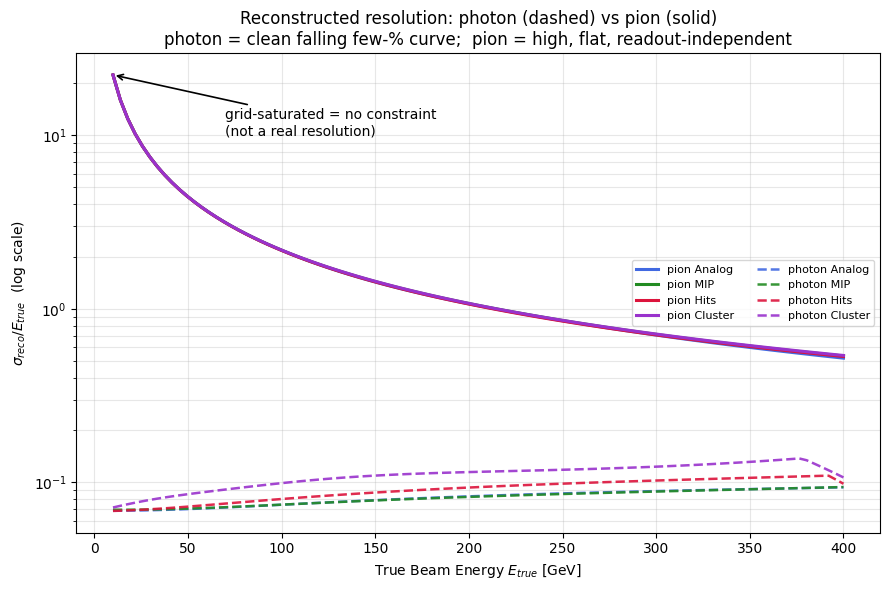

=== sigma_reco/E_true: photon vs pion (Analog readout) ===
  E= 10 GeV:  photon= 0.0686   pion=22.2500
  E=100 GeV:  photon= 0.0744   pion= 2.1579
  E=300 GeV:  photon= 0.0891   pion= 0.7015

=== pion sigma_reco/E_true across all 4 readouts (note how similar) ===
  E= 10 GeV:  analog=22.250  mip=22.250  hits=22.250  cluster=22.250
  E=100 GeV:  analog= 2.158  mip= 2.162  hits= 2.155  cluster= 2.167
  E=300 GeV:  analog= 0.702  mip= 0.709  hits= 0.703  cluster= 0.712

At low E the four pion values collapse onto the SAME number -- that is the
Neyman band spanning the whole energy grid (no constraint), not a resolution.


In [11]:
# (C) DASHBOARD OVERLAY -- photon vs pion sigma_reco/E_true on the SAME axes.
#
# Reuse the EXACT same helpers as the pion side above (get_interpolators ->
# reco_metrics_over_grid) so the two curves are computed identically. The pion
# results live in `reco` / `interp` from the sections above; here we build the
# photon equivalents from the shipped photon ensembles + photon npz.

PHOTON_ENS_DIR = os.path.join(CALOMAPS_HOME, "models", "saved_ensembles_gpu_v2")
PHOTON_NPZ     = os.path.join(CALOMAPS_HOME, "models", "decal_extracted_data.npz")
PHOTON_FILES   = {"True Analog": "ens_analog.pth", "MIP Proxy": "ens_mip.pth",
                  "Raw Hits": "ens_hits.pth", "Naive 2D Clustering": "ens_cluster.pth"}

# --- guard: photon assets must exist, else skip gracefully ------------------
_missing = [p for p in [PHOTON_NPZ] +
            [os.path.join(PHOTON_ENS_DIR, f) for f in PHOTON_FILES.values()]
            if not os.path.exists(p)]
PHOTON_OK = (len(_missing) == 0)

if not PHOTON_OK:
    print("Photon comparison assets not found:")
    for p in _missing:
        print("   missing:", p)
    print("\n--> Run the photon notebooks 02 and 03 first to enable this comparison.")
    print("    (Skipping the photon-vs-pion overlay; the pion results above stand on their own.)")
else:
    # Load the 4 photon ensembles with the SAME load_ensemble call used for pions.
    photon_ensembles = {}
    for name, fname in PHOTON_FILES.items():
        ens_p, xp_, yp_ = load_ensemble(os.path.join(PHOTON_ENS_DIR, fname), device)
        photon_ensembles[name] = (ens_p, xp_, yp_)

    # SAME inversion grid as the pion side (e_grid_inv from section 6).
    photon_interp = {name: get_interpolators(ens, xm_, ym_, device, e_grid_inv)
                     for name, (ens, xm_, ym_) in photon_ensembles.items()}
    photon_reco = {
        "Analog":  reco_metrics_over_grid(*photon_interp["True Analog"]),
        "MIP":     reco_metrics_over_grid(*photon_interp["MIP Proxy"]),
        "Hits":    reco_metrics_over_grid(*photon_interp["Raw Hits"]),
        "Cluster": reco_metrics_over_grid(*photon_interp["Naive 2D Clustering"]),
    }

    # The Neyman grid edge: invert_brent clips to [lo, hi] = [5, 450] when the
    # objective never changes sign. When sigma saturates, e_reco_hi - e_reco_lo
    # spans nearly the whole grid -> the same value for every readout. Flag it.
    et_p   = photon_reco["Analog"][0]
    et_pi  = reco["Analog"][0]
    GRID_HALFWIDTH = (450.0 - 5.0) / 2.0   # = 222.5 GeV; sigma/E ~ this/E means "no constraint"

    fig, ax = plt.subplots(figsize=(9, 6))
    # Pion sigma/E -- high, flat, readout-independent.
    for key in ("Analog", "MIP", "Hits", "Cluster"):
        e_t, _, res = reco[key]
        ax.plot(e_t, res, color=READOUT_COLORS[key], lw=2.2, ls="-",
                label=f"pion {key}")
    # Photon sigma/E -- clean falling few-% curve.
    for key in ("Analog", "MIP", "Hits", "Cluster"):
        e_t, _, res = photon_reco[key]
        ax.plot(e_t, res, color=READOUT_COLORS[key], lw=1.8, ls="--", alpha=0.9,
                label=f"photon {key}")

    # Annotate the grid-saturated pion low-E point(s): sigma/E ~ grid halfwidth / E.
    sat_curve = GRID_HALFWIDTH / et_pi
    # find low-E pion points that sit near the saturation envelope (within 10%)
    res_pi_analog = reco["Analog"][2]
    near_sat = np.where(res_pi_analog > 0.9 * sat_curve)[0]
    if near_sat.size:
        j = near_sat[0]            # lowest-E saturated point
        ax.annotate("grid-saturated = no constraint\n(not a real resolution)",
                    xy=(et_pi[j], res_pi_analog[j]),
                    xytext=(et_pi[j] + 60, res_pi_analog[j] * 0.45),
                    fontsize=10, color="black",
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

    ax.set_yscale("log")           # log y so the few-% photon and ~O(1-20) pion both fit
    ax.set_xlabel("True Beam Energy $E_{true}$ [GeV]")
    ax.set_ylabel(r"$\sigma_{reco}/E_{true}$  (log scale)")
    ax.set_title("Reconstructed resolution: photon (dashed) vs pion (solid)\n"
                 "photon = clean falling few-% curve;  pion = high, flat, readout-independent")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(ncol=2, fontsize=8, loc="center right")
    plt.tight_layout()
    plt.show()

    # Headline numbers for the prose below.
    print("=== sigma_reco/E_true: photon vs pion (Analog readout) ===")
    for energy in (10, 100, 300):
        ip  = np.argmin(np.abs(et_p  - energy))
        ipi = np.argmin(np.abs(et_pi - energy))
        print(f"  E={energy:>3d} GeV:  photon={photon_reco['Analog'][2][ip]:7.4f}   "
              f"pion={reco['Analog'][2][ipi]:7.4f}")
    print("\n=== pion sigma_reco/E_true across all 4 readouts (note how similar) ===")
    for energy in (10, 100, 300):
        ipi = np.argmin(np.abs(et_pi - energy))
        vals = "  ".join(f"{k.lower()}={reco[k][2][ipi]:6.3f}" for k in
                         ("Analog", "MIP", "Hits", "Cluster"))
        print(f"  E={energy:>3d} GeV:  {vals}")
    print("\nAt low E the four pion values collapse onto the SAME number -- that is the\n"
          "Neyman band spanning the whole energy grid (no constraint), not a resolution.")

### Closure scatter: $E_{reco}$ vs $E_{true}$, photon vs pion

The overlay above is the headline. This scatter shows the *same* failure
per-event. For a sample of events we feed each event's measured readout through
the inverse surrogate and plot the reconstructed energy against the truth. A
working calorimeter puts points on the `y = x` diagonal (photons do). The pion
points form a near-vertical, uncorrelated smear: the readout barely changes with
true energy, so the inversion cannot tell 10 GeV from 300 GeV — exactly the "no
constraint" statement, now per event.

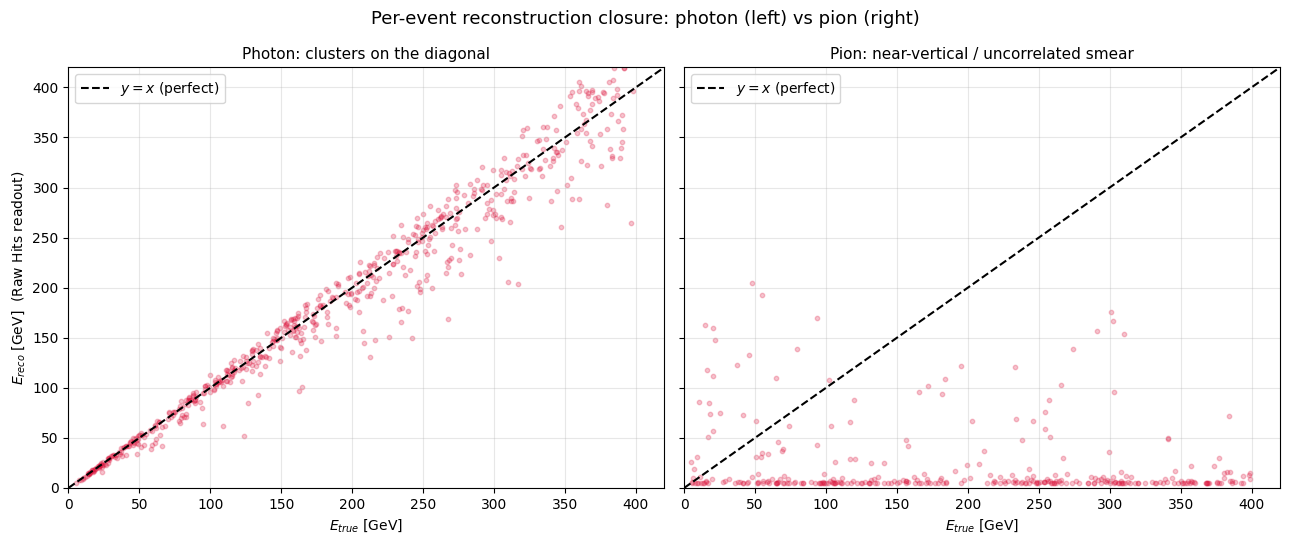

corr(E_reco, E_true)  photon = 0.979   (near 1 = clusters on the diagonal)
corr(E_reco, E_true)  pion   = 0.065   (near 0 = uncorrelated smear, no energy information)


In [12]:
# (D) CLOSURE SCATTER -- E_reco vs E_true per event, photon vs pion.
#
# For a sample of events: take the observed readout y_obs, invert it through the
# median surrogate (invert_brent on f_med) to get E_reco, scatter vs E_true.
# Same inversion call used everywhere above. Uses the "Raw Hits" readout (most
# directly tied to deposited signal) for both species.

if not PHOTON_OK:
    print("Photon assets missing -- skipping the photon-vs-pion closure scatter.")
    print("--> Run the photon notebooks 02 and 03 first to enable this comparison.")
else:
    rng = np.random.RandomState(0)

    def reco_scatter(truth_arr, readout_arr, f_med, n=600):
        # Restrict to events with a usable (positive) readout, then subsample.
        m = (truth_arr > 0) & (readout_arr > 0)
        idx = np.where(m)[0]
        if idx.size > n:
            idx = rng.choice(idx, size=n, replace=False)
        e_true = truth_arr[idx]
        e_reco = np.array([invert_brent(float(readout_arr[k]), f_med) for k in idx])
        return e_true, e_reco

    # Pion: reuse this notebook's loaded arrays + the pion Raw-Hits interpolator.
    f_med_pi = interp["Raw Hits"][1]
    et_pi_s, er_pi_s = reco_scatter(all_truth, all_hits, f_med_pi)

    # Photon: load the photon npz arrays + the photon Raw-Hits interpolator.
    pdat = np.load(PHOTON_NPZ)
    f_med_ph = photon_interp["Raw Hits"][1]
    et_ph_s, er_ph_s = reco_scatter(pdat["all_truth"], pdat["all_hits"], f_med_ph)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
    lim = (0, 420)
    for ax, (et_s, er_s, title, col) in zip(
            axes,
            [(et_ph_s, er_ph_s, "Photon: clusters on the diagonal", READOUT_COLORS["Hits"]),
             (et_pi_s, er_pi_s, "Pion: near-vertical / uncorrelated smear", READOUT_COLORS["Hits"])]):
        ax.scatter(et_s, er_s, s=10, alpha=0.25, color=col)
        ax.plot(lim, lim, "k--", lw=1.5, label="$y = x$ (perfect)")
        ax.set_xlim(*lim); ax.set_ylim(*lim)
        ax.set_xlabel("$E_{true}$ [GeV]")
        ax.set_title(title, fontsize=11)
        ax.legend(loc="upper left")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("$E_{reco}$ [GeV]  (Raw Hits readout)")
    fig.suptitle("Per-event reconstruction closure: photon (left) vs pion (right)", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Quantify: correlation of E_reco with E_true is the one-number summary.
    def safe_corr(a, b):
        if a.size < 2 or np.std(a) == 0 or np.std(b) == 0:
            return float("nan")
        return float(np.corrcoef(a, b)[0, 1])
    print(f"corr(E_reco, E_true)  photon = {safe_corr(et_ph_s, er_ph_s):.3f}   "
          f"(near 1 = clusters on the diagonal)")
    print(f"corr(E_reco, E_true)  pion   = {safe_corr(et_pi_s, er_pi_s):.3f}   "
          f"(near 0 = uncorrelated smear, no energy information)")

## Verdict: pion energy is *not* reconstructable from these ECAL readouts

Read the overlay and the scatter together, and be honest about what they say. This
is **not** the photon story with worse numbers. It is a different outcome:

- **Photons** give a clean, falling `σ_reco/E_true ≈ a/√E` curve at the **few-percent**
  level — a working electromagnetic calorimeter.
- **Pions** give a `σ_reco/E_true` that is **huge** (order ~0.7 at 300 GeV, ~2 at 100 GeV)
  **and nearly the same for all four readouts**. At low energy the four readout
  curves collapse onto a **single saturated value** (~20+): that number is the Neyman
  band spanning essentially the *entire* energy grid. It means the readout places
  **no constraint** on the energy — it is an **artifact of grid saturation, not a
  resolution** you can quote. Reading it as a "resolution of ~20" would be wrong; the
  honest statement is "the energy is unmeasured."

That all four readouts agree on the pion failure is the tell: if a smarter readout
(MIPs, hits, clustering) could recover the energy, the curves would separate. They do
not. The information simply is not there in an EM-only stack.

### Why this is physically correct

The DECAL is ~25 radiation lengths (`X₀`) deep but only a **fraction of one nuclear
interaction length** (`λ_I`). A charged pion therefore does one of two things, neither
of which encodes its energy in the deposited signal:

1. **MIP punch-through (common):** the π⁺ crosses the whole stack as a
   minimum-ionizing particle, depositing ~a fixed energy *per unit length* that is
   **independent of its beam energy**. A 10 GeV and a 300 GeV punch-through look nearly
   identical in every readout.
2. **Hadronic interaction at random depth:** a nuclear interaction in the tungsten
   starts a messy shower, but **where** it starts (and how much leaks out the back)
   is random event to event, and only a fraction of `λ_I` is contained anyway. The
   visible energy is a wildly fluctuating, badly-sampled fraction of the true energy.

Either way, the readout↔energy map is flat-or-random rather than monotonic, so the
inversion has nothing to grip. **This is exactly why hadron calorimeters exist** — a
deep, many-`λ_I` sampling structure (often with dual-readout or software compensation)
is required to measure hadron energy. The few-percent photon curve sitting right next
to the flat pion line **is the lesson** of this notebook: same detector, same
reconstruction, opposite outcome, because of `X₀` vs `λ_I`.

### One open direction (does not change the verdict)

A small amount could be clawed back by **not** treating all pions alike: tag the
**interacting subset** (events with a clear hadronic shower, e.g. a hit/energy spike
above the punch-through band) and use the **longitudinal profile** (`profile_sum` /
`profile_counts` in the npz) to constrain the shower start and containment. That is a
research direction, not a fix — for the inclusive π⁺ sample in an EM-only calorimeter,
energy reconstruction fails, and the dashboard above shows it.

### Panel-by-panel, on the pion dashboard above

- **Panel 1 — Linearity** (`E_reco/E_true`): sits at 1.0 *by construction* (we invert
  the median with itself), so it is **not** evidence of success — see
  [`docs/handbook.md`](../docs/handbook.md) §13.1. Ignore it as a quality metric here.
- **Panel 2 — Resolution** (`σ_reco/E_true`): high and flat, with the low-E points
  **pinned to the grid-saturation value** (no constraint). This is the panel that
  carries the verdict.
- **Panel 3 — Stochastic** (`σ/E` vs `1/√E`): not a straight line through the origin —
  there is no meaningful `a/√E` to fit, because the response is not a sampled-energy
  measurement at all.

For physics interpretation see [`docs/DECAL_pipeline.md`](../docs/DECAL_pipeline.md)
§6 and [`docs/handbook.md`](../docs/handbook.md) §13.

## Suggested follow-up experiments

1. **Photon vs pion, head to head**: the overlay + closure scatter above already
   build this from the shipped photon ensembles. Next step: tag the **interacting**
   π⁺ subset (a hit/energy spike above the punch-through band) and use the
   longitudinal profile (`profile_sum`/`profile_counts`) to see how much of the
   energy can be recovered for that subset alone — an open direction, not a fix.
2. **Pixel pitch scan**: re-run the entire pipeline at 25, 50, 200 µm pixel pitch
   (edit `ECal_cell_size` in `geometry/SiD_TestBeam.xml`, regenerate the π⁺ sim,
   re-extract, retrain). Plot how the saturation knee moves for pions.
3. **Heavier hadrons**: change `gun.particle` in `sim/run_sim.py` to `"proton"` or
   `"kaon+"` and re-run 02/03 for that species. How does the punch-through fraction
   and resolution change with hadron type?
4. **More models per ensemble**: edit `num_models=20` in
   `analysis/train_ensembles.py`. Does the resolution prediction tighten with more
   bootstrap samples — and does the pion case need more members than the photon
   case to stabilize given its larger fluctuations?
5. **Held-out test set**: the current linearity panel is trivially perfect because
   we use the same curve for forward and inverse. Modify the pipeline to
   bootstrap-resample real events and reconstruct each one — what does pion
   linearity look like then?